<a href="https://colab.research.google.com/github/Aakarsh0519/Room_Expense_Traker/blob/main/Copy_of_House_price_prediction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from google.colab import files
uploaded = files.upload()

Saving House Price Prediction Dataset.csv to House Price Prediction Dataset.csv


In [ ]:
import numpy as np
import pandas as pd

In [ ]:
data = pd.read_csv('House Price Prediction Dataset.csv')
data.head()

,Id,Area,Bedrooms,Bathrooms,Floors,YearBuilt,Location,Condition,Garage,Price
0,1,1360,5,4,3,1970,Downtown,Excellent,No,149919
1,2,4272,5,4,3,1958,Downtown,Excellent,No,424998
2,3,3592,2,2,3,1938,Downtown,Good,No,266746
3,4,966,4,2,2,1902,Suburban,Fair,Yes,244020
4,5,4926,1,4,2,1975,Downtown,Fair,Yes,636056


In [ ]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 10 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   Id         2000 non-null   int64 
 1   Area       2000 non-null   int64 
 2   Bedrooms   2000 non-null   int64 
 3   Bathrooms  2000 non-null   int64 
 4   Floors     2000 non-null   int64 
 5   YearBuilt  2000 non-null   int64 
 6   Location   2000 non-null   object
 7   Condition  2000 non-null   object
 8   Garage     2000 non-null   object
 9   Price      2000 non-null   int64 
dtypes: int64(7), object(3)
memory usage: 156.4+ KB


In [ ]:
data.isnull().sum()


,0
Id,0
Area,0
Bedrooms,0
Bathrooms,0
Floors,0
YearBuilt,0
Location,0
Condition,0
Garage,0
Price,0


In [ ]:
data= data.dropna()

In [ ]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 10 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   Id         2000 non-null   int64 
 1   Area       2000 non-null   int64 
 2   Bedrooms   2000 non-null   int64 
 3   Bathrooms  2000 non-null   int64 
 4   Floors     2000 non-null   int64 
 5   YearBuilt  2000 non-null   int64 
 6   Location   2000 non-null   object
 7   Condition  2000 non-null   object
 8   Garage     2000 non-null   object
 9   Price      2000 non-null   int64 
dtypes: int64(7), object(3)
memory usage: 156.4+ KB


In [ ]:
data.nunique()

,0
Id,2000
Area,1622
Bedrooms,5
Bathrooms,4
Floors,3
YearBuilt,124
Location,4
Condition,4
Garage,2
Price,1999


In [ ]:
data['Area'].unique()

array([1360, 4272, 3592, ...,  865, 2174, 4062])

In [ ]:
numerical_cols_name = data.select_dtypes(include=['int', 'float']).drop(['Price'], axis=1)
object_cols_name = data.select_dtypes(include=['object'])
target_col = data.Price

In [ ]:
numerical_cols_name

,Id,Area,Bedrooms,Bathrooms,Floors,YearBuilt
0,1,1360,5,4,3,1970
1,2,4272,5,4,3,1958
2,3,3592,2,2,3,1938
3,4,966,4,2,2,1902
4,5,4926,1,4,2,1975
...,...,...,...,...,...,...
1995,1996,4994,5,4,3,1923
1996,1997,3046,5,2,1,2019
1997,1998,1062,5,1,2,1903
1998,1999,4062,3,1,2,1936


In [ ]:
object_cols_name

,Location,Condition,Garage
0,Downtown,Excellent,No
1,Downtown,Excellent,No
2,Downtown,Good,No
3,Suburban,Fair,Yes
4,Downtown,Fair,Yes
...,...,...,...
1995,Suburban,Poor,No
1996,Suburban,Poor,Yes
1997,Rural,Poor,No
1998,Urban,Excellent,Yes


In [ ]:
data.dtypes

,0
Id,int64
Area,int64
Bedrooms,int64
Bathrooms,int64
Floors,int64
YearBuilt,int64
Location,object
Condition,object
Garage,object
Price,int64


In [ ]:
numerical_cols_name = numerical_cols_name.drop('Id', axis=1)
numerical_cols_name

,Area,Bedrooms,Bathrooms,Floors,YearBuilt
0,1360,5,4,3,1970
1,4272,5,4,3,1958
2,3592,2,2,3,1938
3,966,4,2,2,1902
4,4926,1,4,2,1975
...,...,...,...,...,...
1995,4994,5,4,3,1923
1996,3046,5,2,1,2019
1997,1062,5,1,2,1903
1998,4062,3,1,2,1936


In [ ]:
object_cols_name.Location = object_cols_name.Location.replace('-', np.nan)
object_cols_name.Condition = object_cols_name.Condition.replace('-', np.nan)
object_cols_name.Garage = object_cols_name.Garage.replace('-', np.nan)

print(object_cols_name.isnull().sum())

Location     0
Condition    0
Garage       0
dtype: int64


In [ ]:
object_cols_name = object_cols_name.astype('str')
object_cols_name.dtypes

,0
Location,object
Condition,object
Garage,object


In [ ]:
df = pd.concat([numerical_cols_name, object_cols_name], axis=1)
df.columns

Index(['Area', 'Bedrooms', 'Bathrooms', 'Floors', 'YearBuilt', 'Location',
       'Condition', 'Garage'],
      dtype='object')

In [ ]:
df = pd.concat([df,data.Price], axis=1)
df.columns

Index(['Area', 'Bedrooms', 'Bathrooms', 'Floors', 'YearBuilt', 'Location',
       'Condition', 'Garage', 'Price'],
      dtype='object')

In [ ]:
df['Area'] = df['Area'].astype(float)
df['Bedrooms'] = df['Bedrooms'].astype(float)
df['Bathrooms'] = df['Bathrooms'].astype(float)
df['Floors'] = df['Floors'].astype(float)
df['YearBuilt'] = df['YearBuilt'].astype(float)
df['Price'] = df['Price'].astype(float)

In [ ]:
df.dtypes

,0
Area,float64
Bedrooms,float64
Bathrooms,float64
Floors,float64
YearBuilt,float64
Location,object
Condition,object
Garage,object
Price,float64


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 9 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   Area       2000 non-null   float64
 1   Bedrooms   2000 non-null   float64
 2   Bathrooms  2000 non-null   float64
 3   Floors     2000 non-null   float64
 4   YearBuilt  2000 non-null   float64
 5   Location   2000 non-null   object 
 6   Condition  2000 non-null   object 
 7   Garage     2000 non-null   object 
 8   Price      2000 non-null   float64
dtypes: float64(6), object(3)
memory usage: 140.8+ KB


In [ ]:
numeric={'Area','Bedrooms','Bathrooms','Floors'}

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

Text(0.5, 1.0, 'Boxplot of Area')

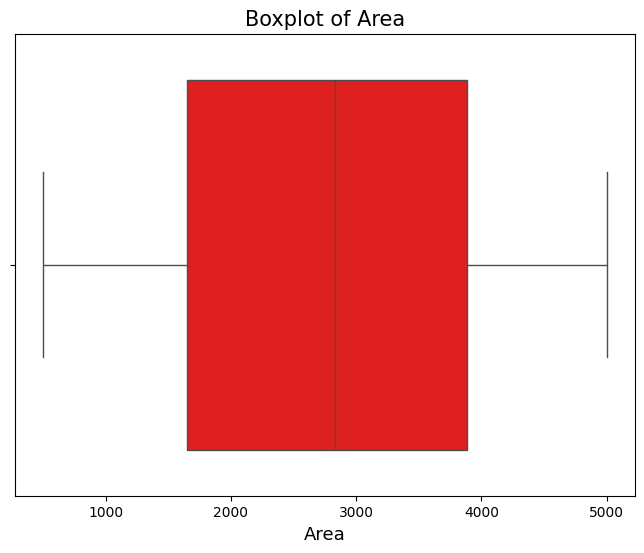

In [ ]:
plt.figure(figsize=(8, 6))

# Create the boxplot for 'Area'
sns.boxplot(x=df['Area'], color='Red')

# Set labels and title if needed
plt.xlabel('Area', fontsize=13)
plt.title('Boxplot of Area', fontsize=15)

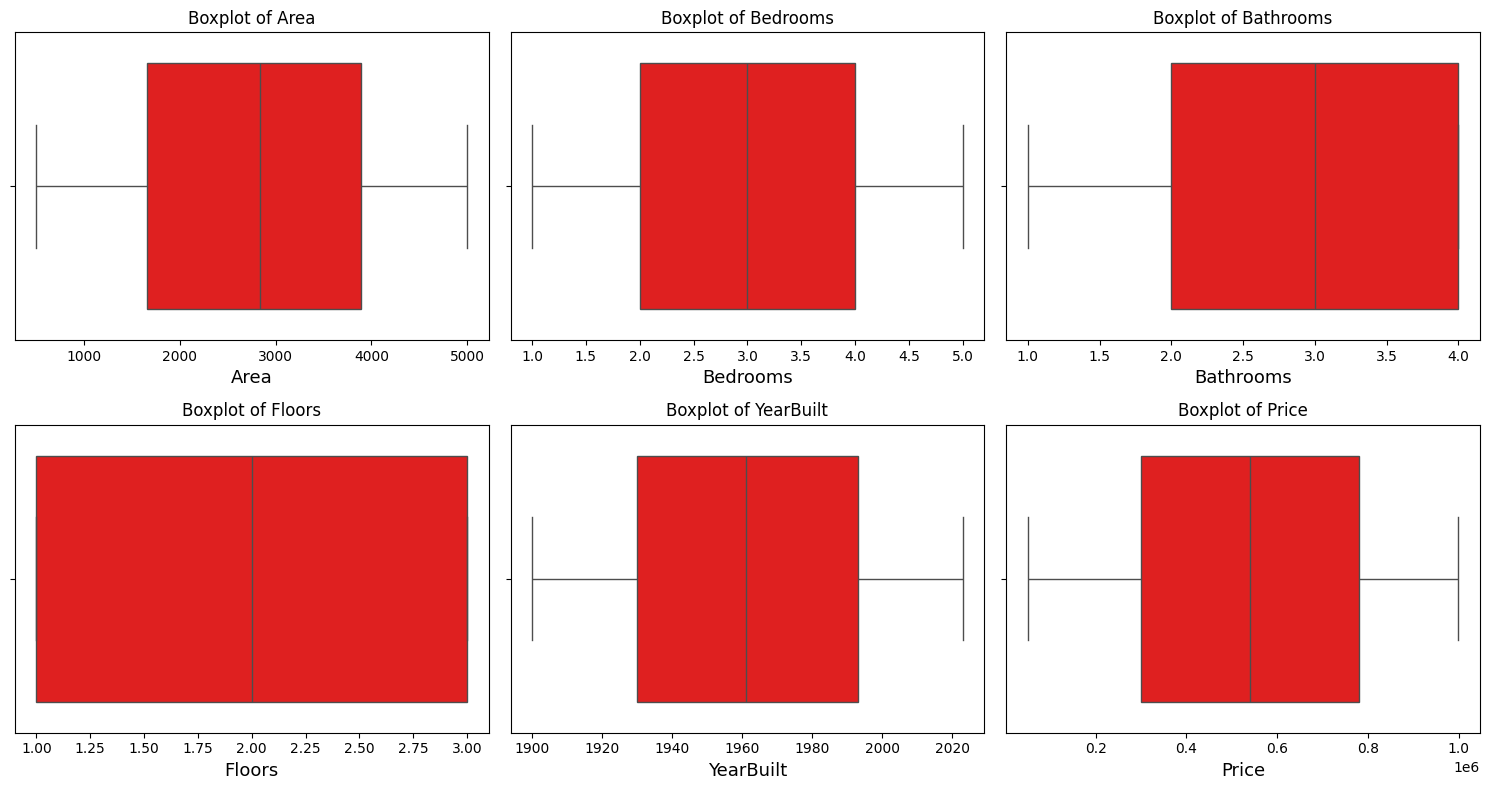

In [ ]:
numeric = ['Area', 'Bedrooms', 'Bathrooms', 'Floors', 'YearBuilt', 'Price']

plt.figure(figsize=(15, 8))
for j, col in enumerate(df[numeric].columns, 1):

    plt.subplot(2, 3, j)

    sns.boxplot(x=df[col], color='red')


    plt.xlabel(col, fontsize=13)


    plt.title(f'Boxplot of {col}')

plt.tight_layout()
plt.show()

In [ ]:
cols = ['Area', 'Bedrooms', 'Bathrooms', 'Floors', 'YearBuilt', 'Price']

# Remove outliers using IQR
for col in cols:
    q1 = df[col].quantile(0.25)
    q3 = df[col].quantile(0.75)
    iqr = q3 - q1
    lower_limit = q1 - 1.5 * iqr
    upper_limit = q3 + 1.5 * iqr
    df = df[(df[col] >= lower_limit) & (df[col] <= upper_limit)]

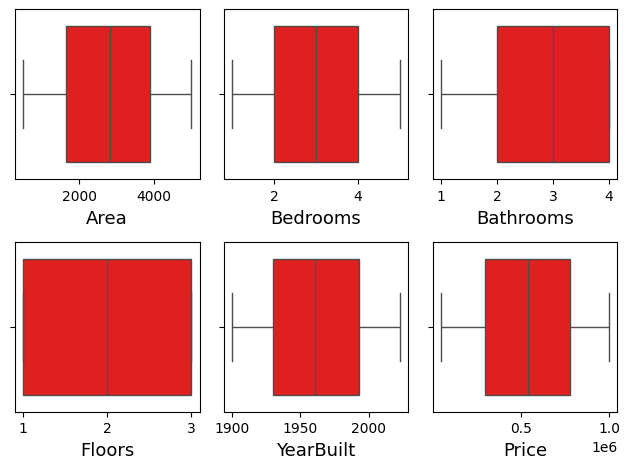

In [ ]:
for j, col in enumerate(df[numeric].columns, 1):
    plt.subplot(2, 3, j)  # Create a subplot grid (2 rows, 3 columns)
    sns.boxplot(x=df[col], color='Red')  # Create boxplot
    plt.xlabel(col, fontsize=13)  # Set x-label
    plt.tight_layout()  # Adjust layout to prevent overlap

# Show the plot
plt.show()

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 9 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   Area       2000 non-null   float64
 1   Bedrooms   2000 non-null   float64
 2   Bathrooms  2000 non-null   float64
 3   Floors     2000 non-null   float64
 4   YearBuilt  2000 non-null   float64
 5   Location   2000 non-null   object 
 6   Condition  2000 non-null   object 
 7   Garage     2000 non-null   object 
 8   Price      2000 non-null   float64
dtypes: float64(6), object(3)
memory usage: 140.8+ KB


In [ ]:
from matplotlib.pyplot import figure

In [ ]:
import warnings
warnings.filterwarnings('ignore')

<Figure size 2000x3000 with 0 Axes>

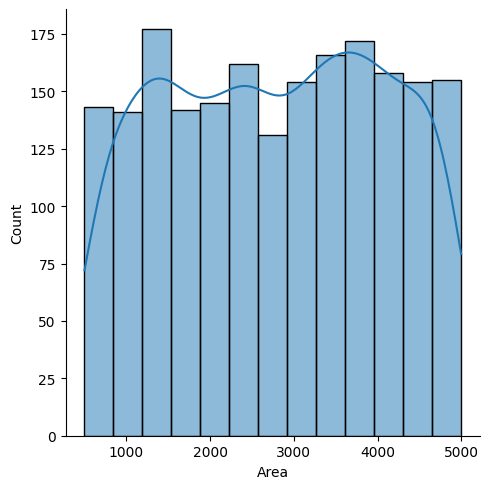

In [ ]:
plt.figure(figsize=(20,30))
sns.displot(data=df, x="Area", kde=True)

<Figure size 2000x3000 with 0 Axes>

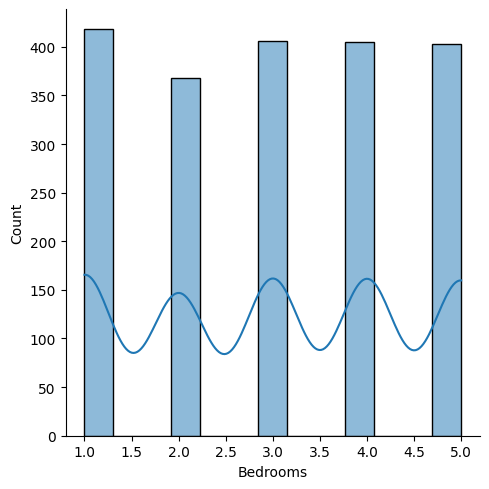

In [ ]:
plt.figure(figsize=(20,30))
sns.displot(data=df, x="Bedrooms", kde=True)

<Axes: xlabel='Price', ylabel='Density'>

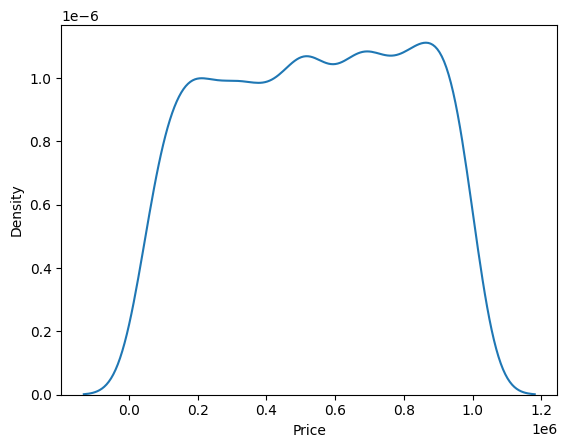

In [ ]:
sns.kdeplot(df['Price'])

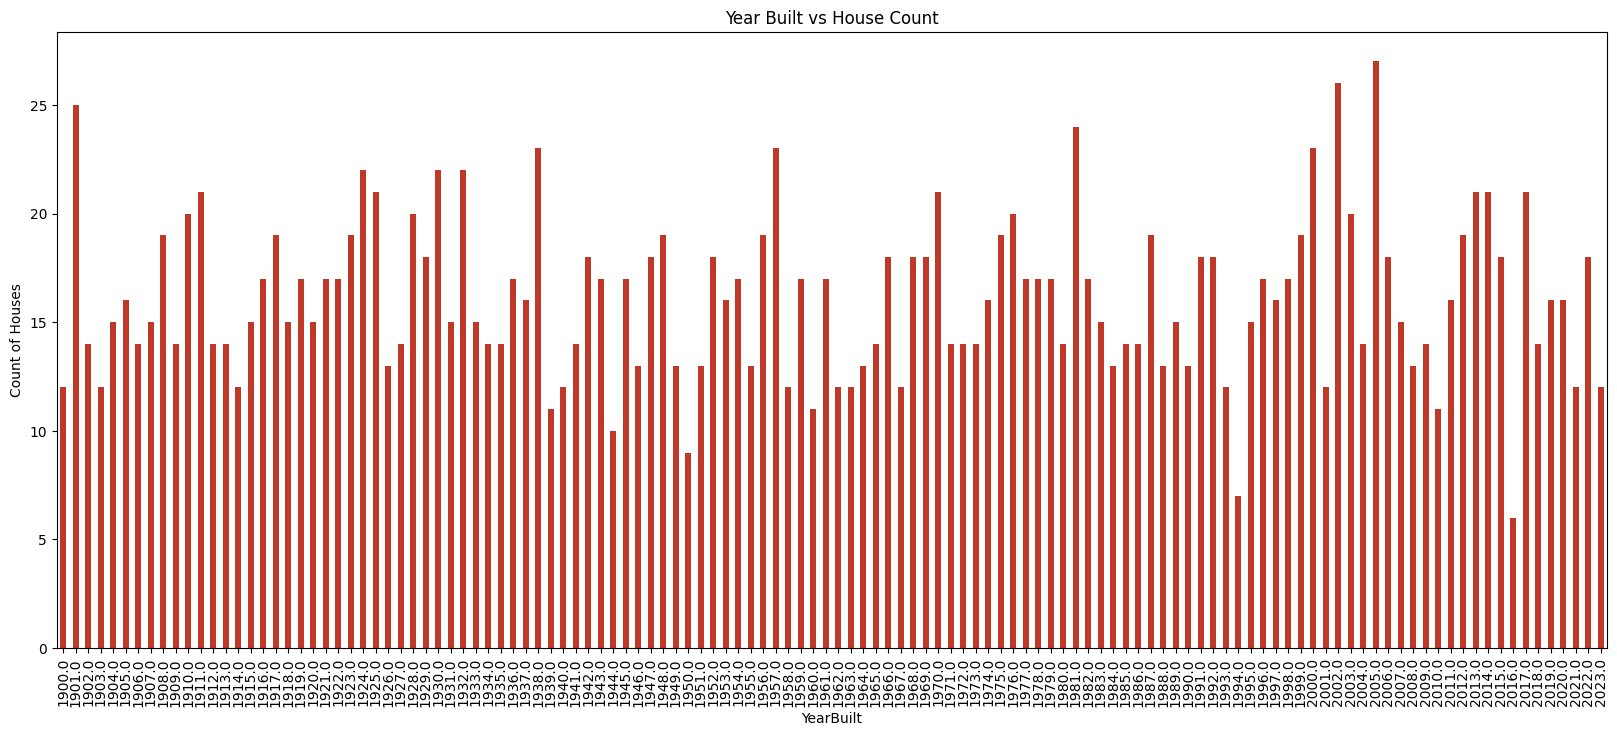

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(20,8))

plt.xlabel('Year Built')
plt.ylabel('Count of Houses')


df['YearBuilt'].value_counts().sort_index().plot(
    kind='bar',
    title='Year Built vs House Count',
    color='#C03928'
)

plt.show()

In [ ]:
df['YearBuilt'].value_counts()

,count
YearBuilt,
2005.0,27
2002.0,26
1901.0,25
1981.0,24
2000.0,23
...,...
2010.0,11
1944.0,10
1950.0,9


<Axes: xlabel='YearBuilt'>

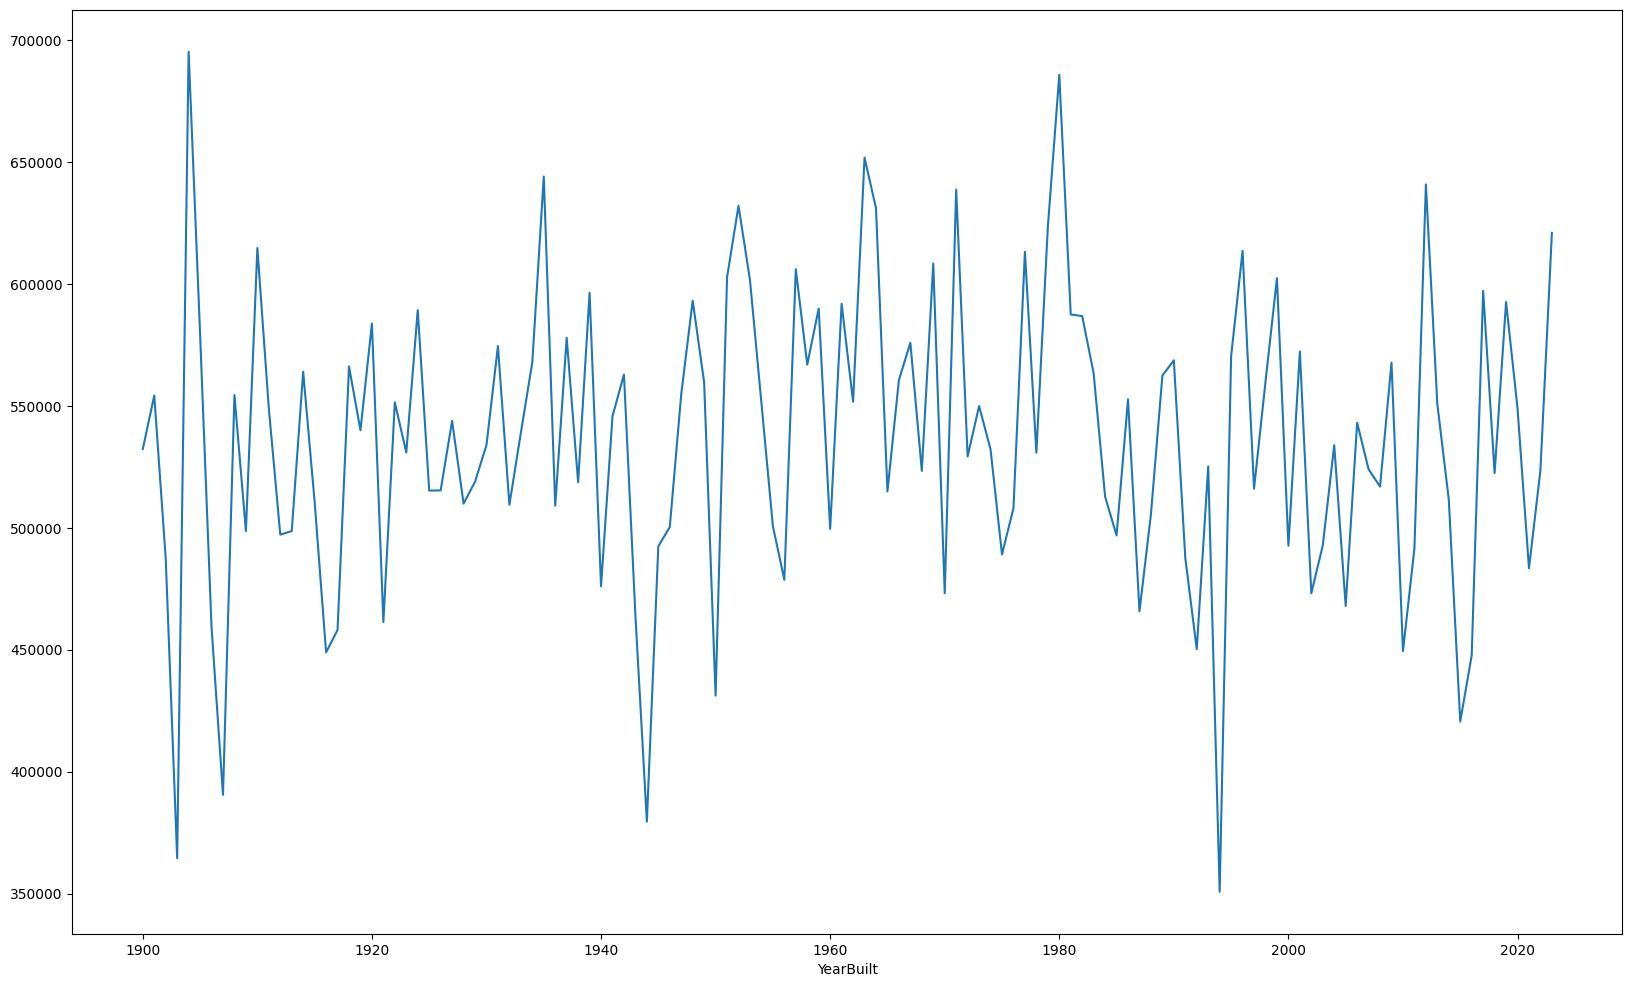

In [ ]:
plt.figure(figsize=(20,12))
year_data = df.groupby('YearBuilt')['Price'].mean()
sns.lineplot(x=year_data.index,y=year_data.values)

In [ ]:
year_data = df.groupby('YearBuilt')['Price'].mean()
year_data

,Price
YearBuilt,
1900.0,532297.583333
1901.0,554257.960000
1902.0,487525.428571
1903.0,364482.333333
1904.0,695236.933333
...,...
2019.0,592602.437500
2020.0,548988.500000
2021.0,483393.750000


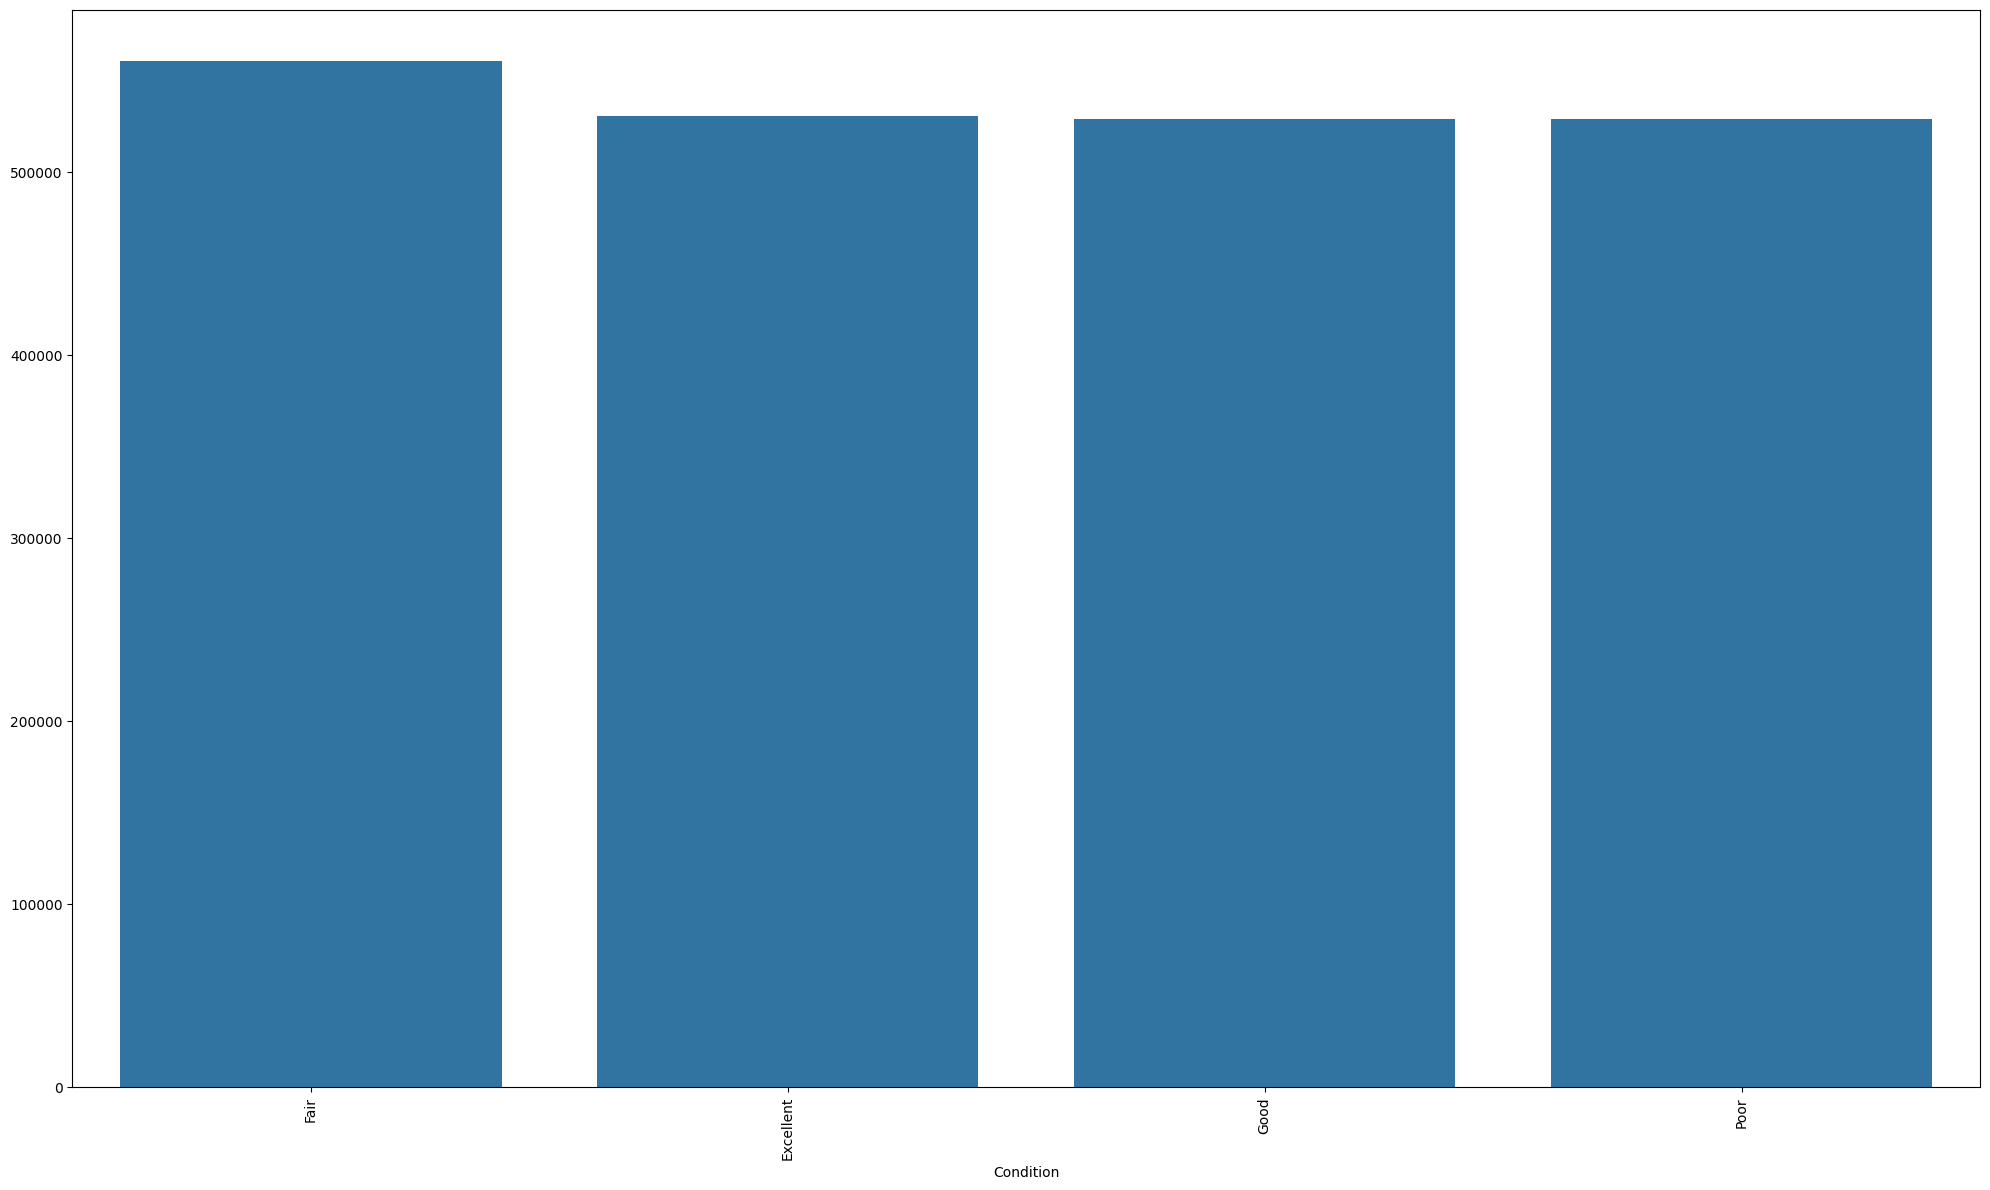

In [ ]:
plt.figure(figsize=(20,12))
year_data = df.groupby('Condition')['Price'].mean().sort_values(ascending=False)
sns.barplot(x=year_data.index,y=year_data.values)
plt.xticks(rotation=90)
plt.tight_layout()

<Axes: xlabel='Garage'>

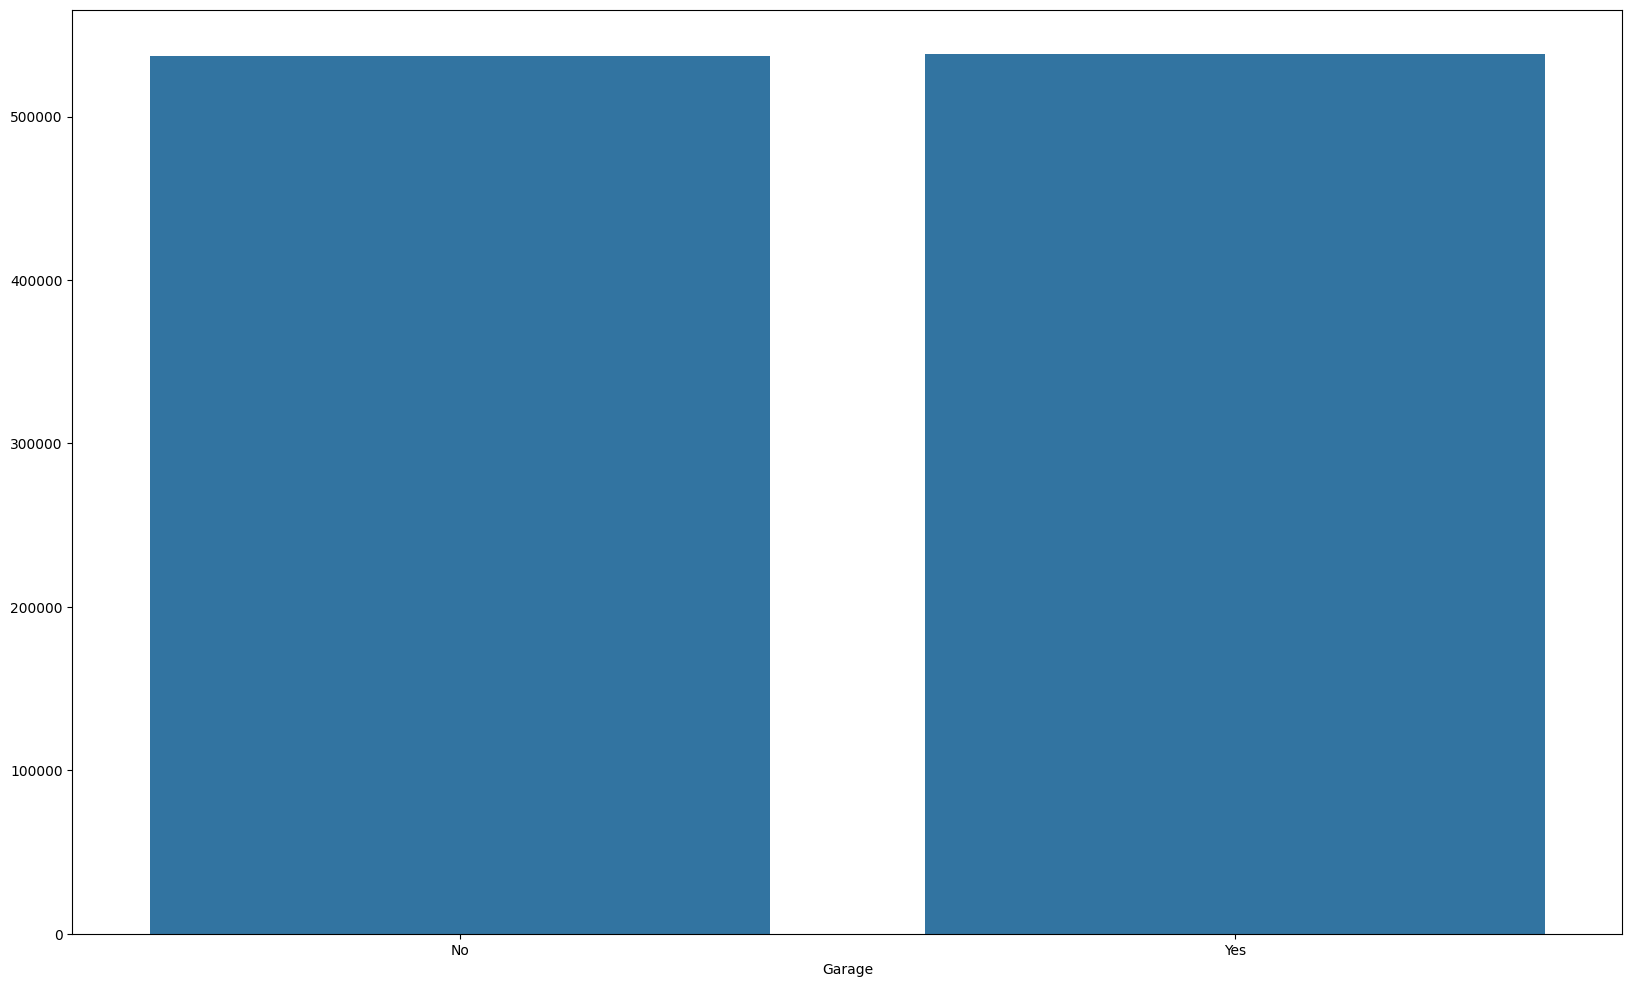

In [ ]:
plt.figure(figsize=(20,12))
data_air = df.groupby('Garage')['Price'].mean().sort_values()
sns.barplot(x=data_air.index, y=data_air.values)

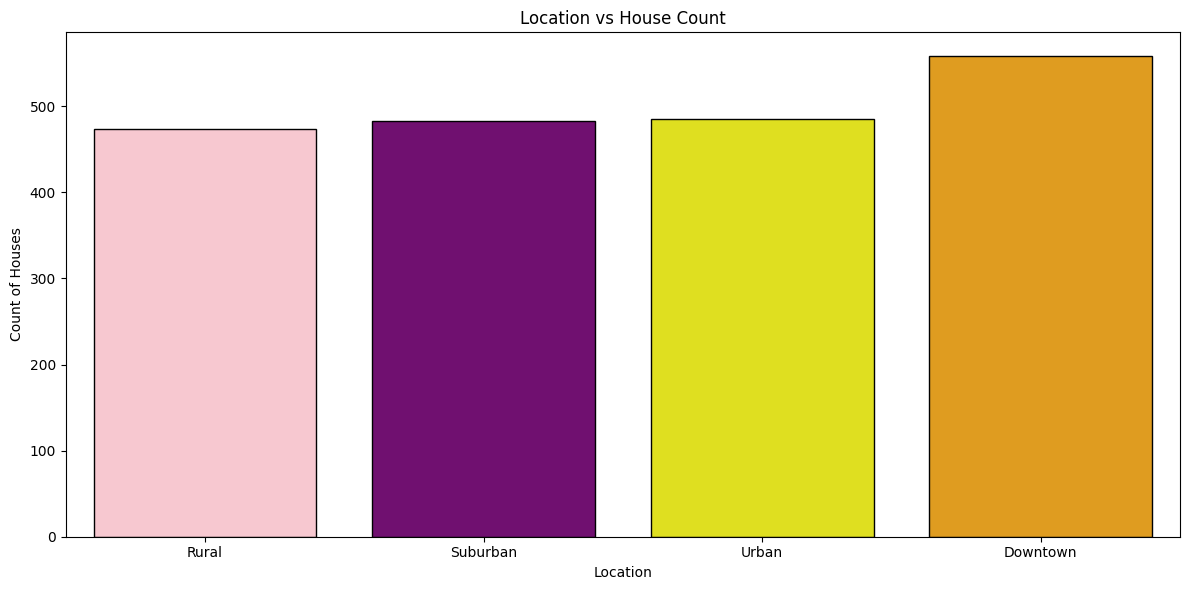

In [ ]:


plt.figure(figsize=(12,6))


color = ['pink','purple','yellow','orange','skyblue','gold','brown']


data_color = df.groupby('Location')['Location'].count().sort_values()


sns.barplot(
    x=data_color.index,
    y=data_color.values,
    palette=color,
    edgecolor='black'
)

plt.xlabel('Location')
plt.ylabel('Count of Houses')
plt.title('Location vs House Count')

plt.tight_layout()

plt.show()

<Axes: xlabel='Location'>

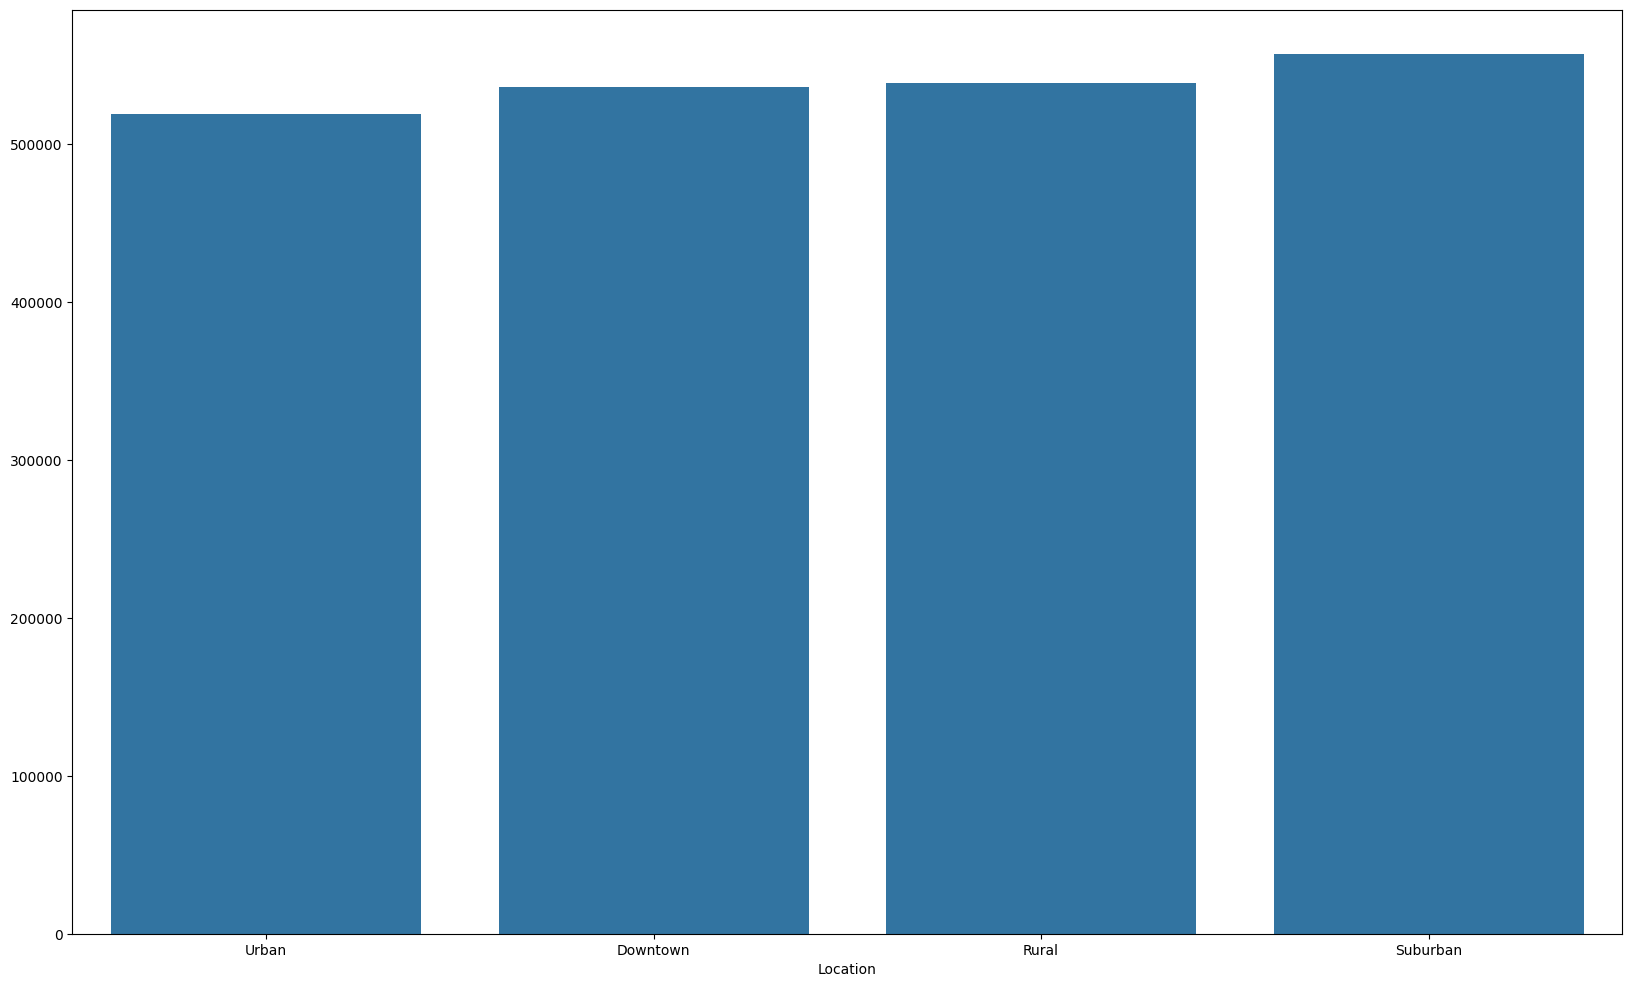

In [ ]:
plt.figure(figsize=(20,12))
data_vol = df.groupby('Location')['Price'].mean().sort_values()
sns.barplot(x=data_vol.index, y=data_vol.values)

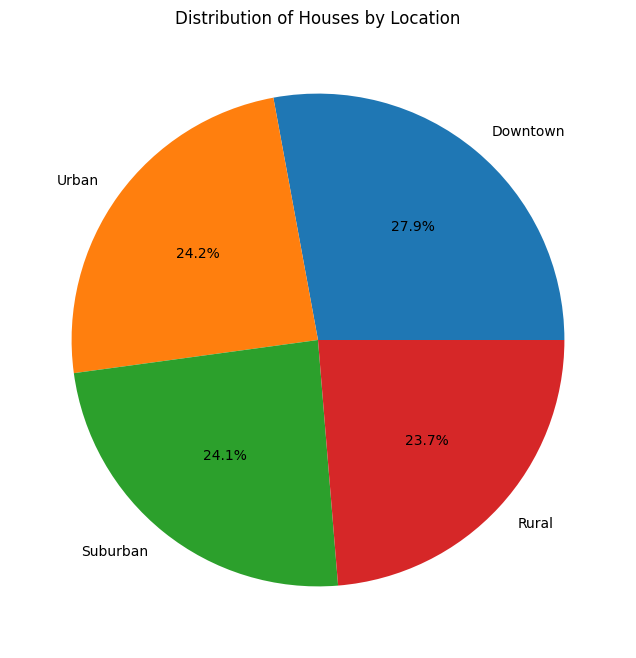

In [ ]:
data_location = df['Location'].value_counts()

plt.figure(figsize=(8,8))

plt.pie(
    data_location,
    autopct='%1.1f%%',
    labels=data_location.index
)

plt.title('Distribution of Houses by Location')

plt.show()
plt.show()

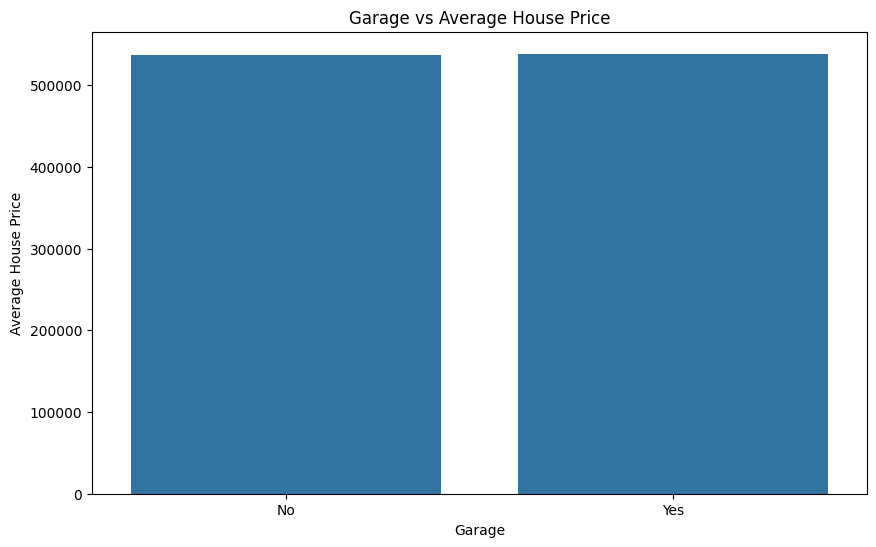

In [ ]:


plt.figure(figsize=(10,6))


data_garage = df.groupby('Garage')['Price'].mean().sort_values()

sns.barplot(
    x=data_garage.index,
    y=data_garage.values
)
plt.xlabel('Garage')
plt.ylabel('Average House Price')
plt.title('Garage vs Average House Price')

plt.show()

In [ ]:
data_Garage = df.groupby('Garage')['Price'].mean().sort_values()

print(data_Garage)

Garage
No     536920.700385
Yes    538492.747401
Name: Price, dtype: float64


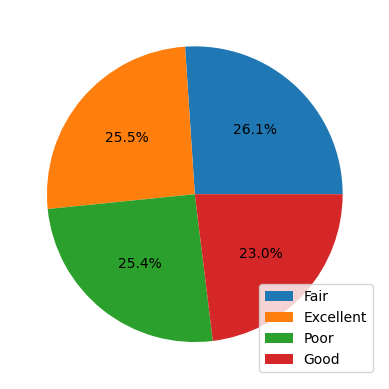

In [ ]:
data_Condition = df['Condition'].value_counts()

plt.pie(data_Condition, autopct='%1.1f%%')
plt.legend(data_Condition.index)

<function matplotlib.pyplot.show(close=None, block=None)>

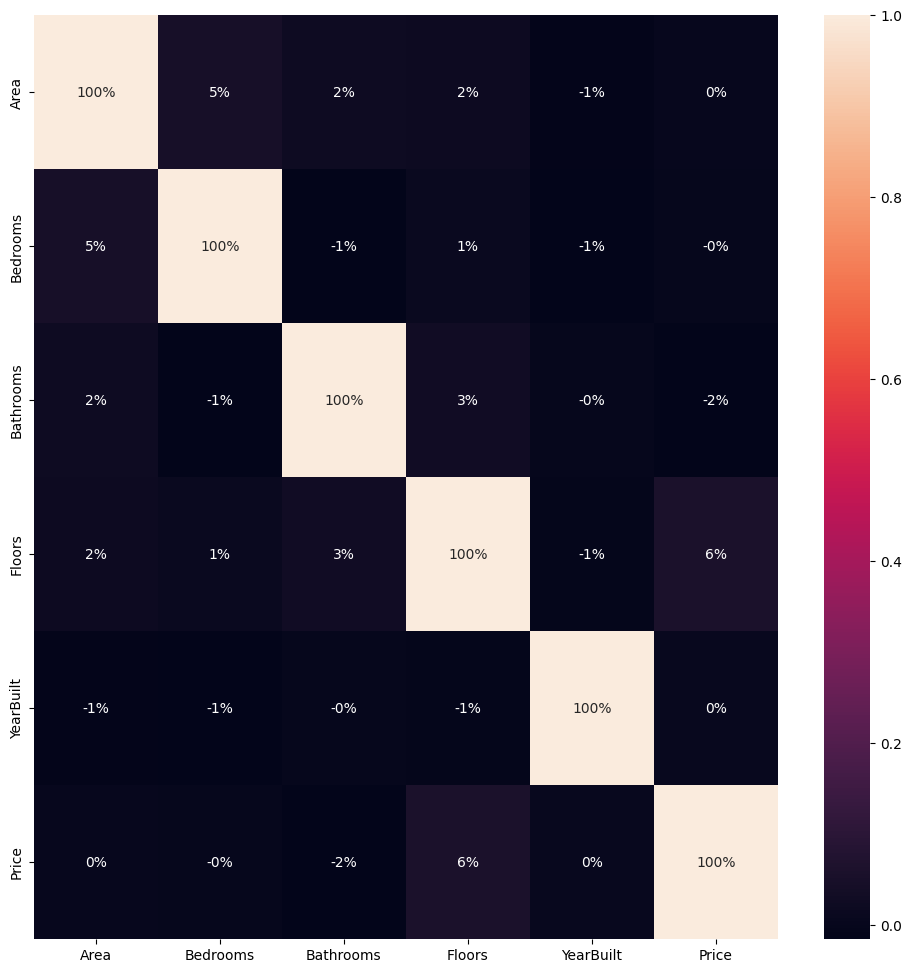

In [ ]:
plt.subplots(figsize=(12,12))
sns.heatmap(df.select_dtypes(include='number').corr(), annot = True, fmt = '0.0%')
plt.show

In [ ]:
corr = df.select_dtypes(include='number').corr()
corr

,Area,Bedrooms,Bathrooms,Floors,YearBuilt,Price
Area,1.000000,0.047523,0.021881,0.017749,-0.011609,0.001542
Bedrooms,0.047523,1.000000,-0.011990,0.010435,-0.014125,-0.003471
Bathrooms,0.021881,-0.011990,1.000000,0.029089,-0.000839,-0.015737
Floors,0.017749,0.010435,0.029089,1.000000,-0.006474,0.055890
YearBuilt,-0.011609,-0.014125,-0.000839,-0.006474,1.000000,0.004845
Price,0.001542,-0.003471,-0.015737,0.055890,0.004845,1.000000


In [ ]:
from statsmodels.stats.outliers_influence import variance_inflation_factor

variables = df[['Area', 'Bedrooms', 'Bathrooms', 'Floors', 'YearBuilt', 'Price']]
vif = pd.DataFrame()
vif["VIF"] = [variance_inflation_factor(variables.values, i) for i in range(variables.shape[1])]
vif["Features"] = variables.columns
vif

,VIF,Features
0,5.635887,Area
1,5.448241,Bedrooms
2,6.300664,Bathrooms
3,7.088184,Floors
4,23.576306,YearBuilt
5,4.797957,Price


In [ ]:
df = df.drop(['Location','Garage'], axis=1)

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 7 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   Area       2000 non-null   float64
 1   Bedrooms   2000 non-null   float64
 2   Bathrooms  2000 non-null   float64
 3   Floors     2000 non-null   float64
 4   YearBuilt  2000 non-null   float64
 5   Condition  2000 non-null   object 
 6   Price      2000 non-null   float64
dtypes: float64(6), object(1)
memory usage: 109.5+ KB


<function matplotlib.pyplot.show(close=None, block=None)>

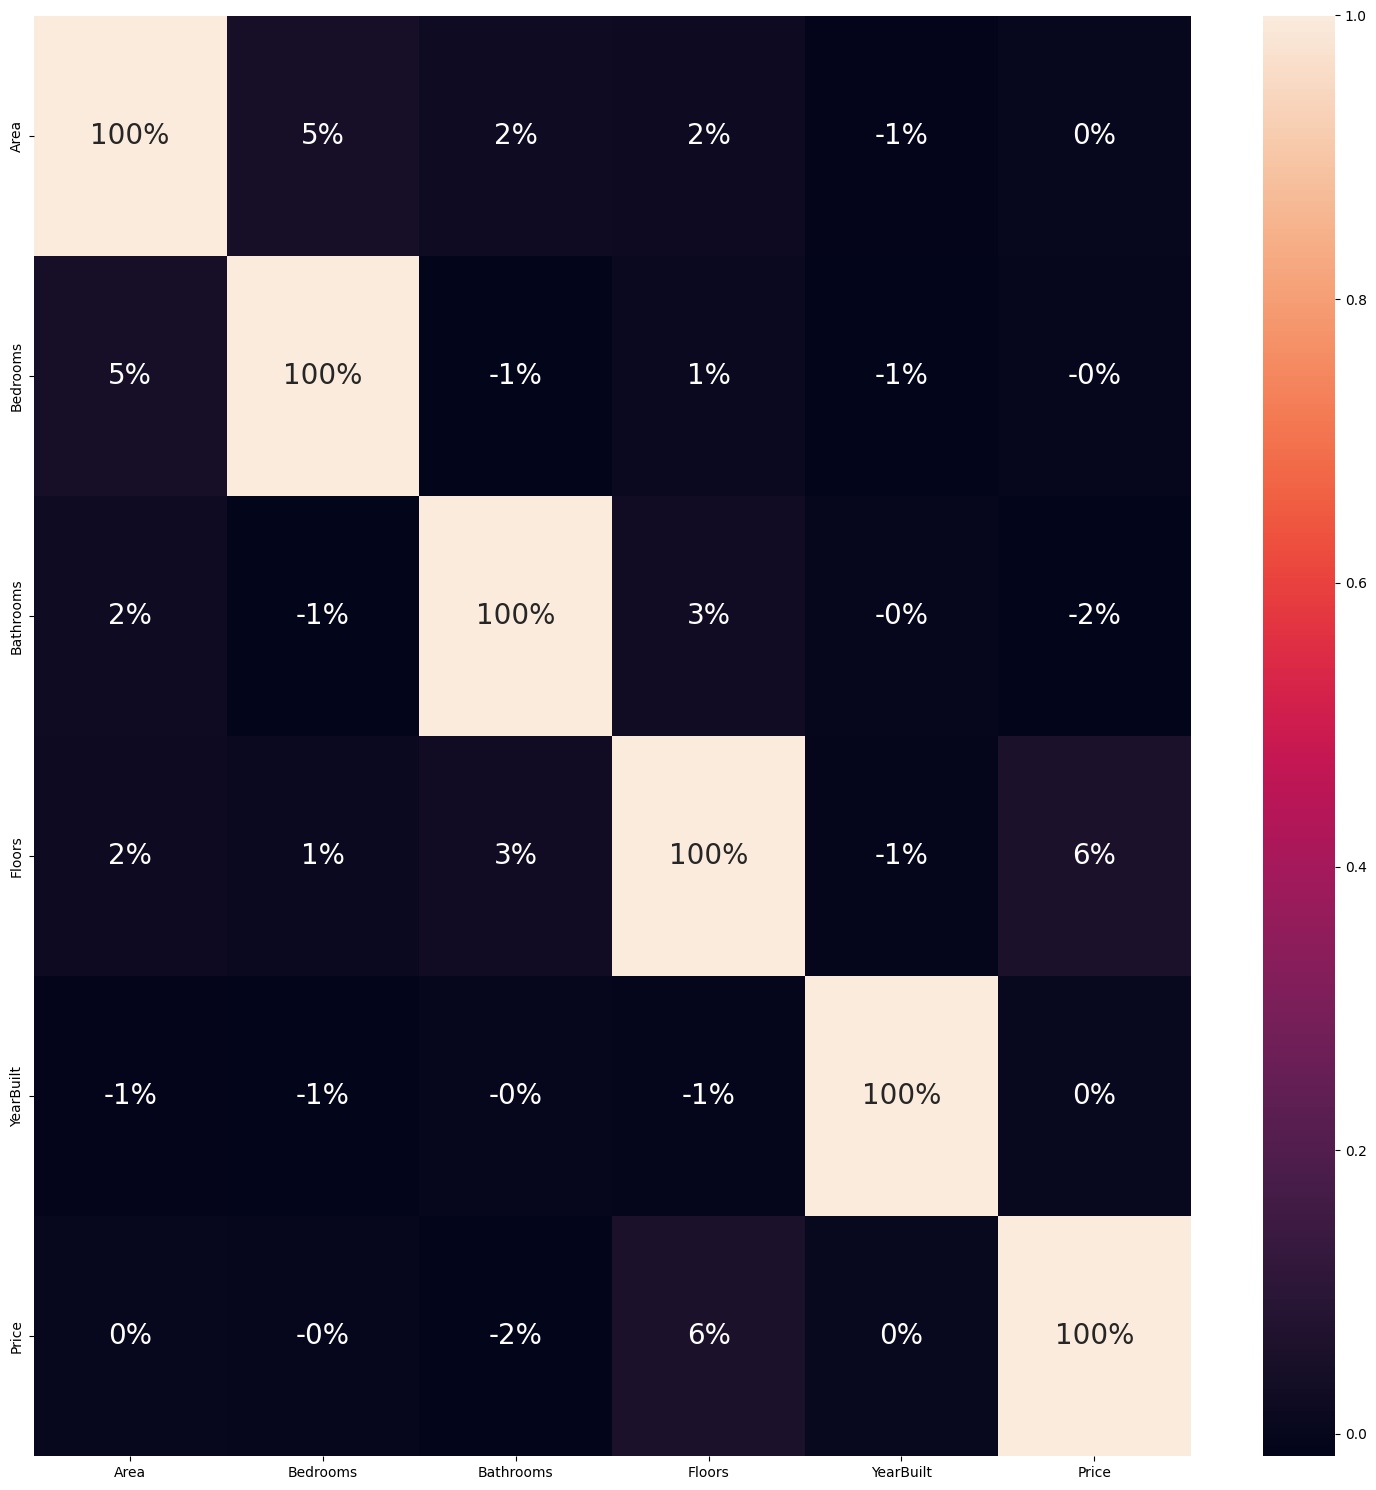

In [ ]:
plt.subplots(figsize=(15,15))
sns.heatmap(df.select_dtypes(include='number').corr(), annot = True, fmt = '0.0%',annot_kws={'size': 20})
# Manually adjust margins
#plt.subplots_adjust(bottom=0.15, top=0.9, left=0.1, right=0.9)
plt.tight_layout()
plt.show

In [ ]:
df.head()

,Area,Bedrooms,Bathrooms,Floors,YearBuilt,Condition,Price
0,1360.0,5.0,4.0,3.0,1970.0,Excellent,149919.0
1,4272.0,5.0,4.0,3.0,1958.0,Excellent,424998.0
2,3592.0,2.0,2.0,3.0,1938.0,Good,266746.0
3,966.0,4.0,2.0,2.0,1902.0,Fair,244020.0
4,4926.0,1.0,4.0,2.0,1975.0,Fair,636056.0


In [ ]:
y=df['Price']
X=df.drop(['Price'],axis=1)

In [ ]:
X.shape

(2000, 6)

In [ ]:
X.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 6 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   Area       2000 non-null   float64
 1   Bedrooms   2000 non-null   float64
 2   Bathrooms  2000 non-null   float64
 3   Floors     2000 non-null   float64
 4   YearBuilt  2000 non-null   float64
 5   Condition  2000 non-null   object 
dtypes: float64(5), object(1)
memory usage: 93.9+ KB


In [ ]:
y.shape

(2000,)

In [ ]:
y.info()

<class 'pandas.core.series.Series'>
RangeIndex: 2000 entries, 0 to 1999
Series name: Price
Non-Null Count  Dtype  
--------------  -----  
2000 non-null   float64
dtypes: float64(1)
memory usage: 15.8 KB


In [ ]:
import pandas as pd
from sklearn.preprocessing import LabelEncoder

In [ ]:
categorical_col = ['Location', 'Condition', 'Garage']

In [ ]:
X.head()

,Area,Bedrooms,Bathrooms,Floors,YearBuilt,Condition
0,1360.0,5.0,4.0,3.0,1970.0,Excellent
1,4272.0,5.0,4.0,3.0,1958.0,Excellent
2,3592.0,2.0,2.0,3.0,1938.0,Good
3,966.0,4.0,2.0,2.0,1902.0,Fair
4,4926.0,1.0,4.0,2.0,1975.0,Fair


In [ ]:
from sklearn.model_selection import train_test_split

x_train, x_test, y_train, y_test = train_test_split(X,y,test_size=0.20, random_state=52)

In [ ]:
x_train.shape

(1600, 6)

In [ ]:
x_test.shape

(400, 6)

In [ ]:
y_train.shape

(1600,)

In [ ]:
y_test.shape

(400,)

In [ ]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error

In [ ]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

# Apply LabelEncoder to the 'Condition' column in x_train and x_test
# 'Location' and 'Garage' columns were previously dropped from df and X
x_train['Condition'] = le.fit_transform(x_train['Condition'])
x_test['Condition'] = le.transform(x_test['Condition'])


In [ ]:
from sklearn import metrics
LRmodel = LinearRegression()
LRmodel.fit(x_train,y_train)
y_pred_lr = LRmodel.predict(x_test)

mae_lr = mean_absolute_error(y_test, y_pred_lr)
mse_lr = mean_squared_error(y_test, y_pred_lr)
rmse_lr = np.sqrt(mean_squared_error(y_test, y_pred_lr))
r2_lr = r2_score(y_test, y_pred_lr)


In [ ]:
print(f"Mean Absolute Error (MAE): {mae_lr}")
print(f"Mean Squared Error (MSE): {mse_lr}")
print(f"Root Mean Squared Error (RMSE): {rmse_lr}")
print(f"R-squared (R²): {r2_lr}")


Mean Absolute Error (MAE): 245843.7240533483
Mean Squared Error (MSE): 78556704294.9363
Root Mean Squared Error (RMSE): 280279.6894085198
R-squared (R²): 0.0015692550073488354


In [ ]:
from sklearn.svm import SVR

In [ ]:
regressor = SVR(kernel='rbf')
regressor.fit(x_train, y_train)
y_pred = regressor.predict(x_test)

In [ ]:
mae_svm = mean_absolute_error(y_test, y_pred)
mse_svm = mean_squared_error(y_test, y_pred)
rmse_svm = np.sqrt(mean_squared_error(y_test, y_pred))
r2_svm = r2_score(y_test, y_pred)

In [ ]:
print(f"Mean Absolute Error (MAE): {mae_svm}")
print(f"Mean Squared Error (MSE): {mse_svm}")
print(f"Root Mean Squared Error (RMSE): {rmse_svm}")
print(f"R-squared (R²): {r2_svm}")

Mean Absolute Error (MAE): 245786.1913408914
Mean Squared Error (MSE): 78696681423.37311
Root Mean Squared Error (RMSE): 280529.2879956977
R-squared (R²): -0.00020980980807916438


In [ ]:
from sklearn.neighbors import KNeighborsRegressor

In [ ]:
knn = KNeighborsRegressor(n_neighbors=25)
knn.fit(x_train, y_train)
predicted = knn.predict(x_test)

In [ ]:
mae_knn = mean_absolute_error(y_test, predicted)
mse_knn = mean_squared_error(y_test, predicted)
rmse_knn = np.sqrt(mean_squared_error(y_test, predicted))
r2_knn = r2_score(y_test, predicted)


In [ ]:
print(f"Mean Absolute Error (MAE): {mae_knn}")
print(f"Mean Squared Error (MSE): {mse_knn}")
print(f"Root Mean Squared Error (RMSE): {rmse_knn}")
print(f"R-squared (R²): {r2_knn}")

Mean Absolute Error (MAE): 250195.4218
Mean Squared Error (MSE): 83078434541.1666
Root Mean Squared Error (RMSE): 288233.29880700214
R-squared (R²): -0.055900499342956156


In [ ]:
from sklearn.ensemble import BaggingRegressor

In [ ]:
bg = BaggingRegressor(n_estimators = 10, random_state =100)
bg.fit(x_train, y_train)
predictbg= bg.predict(x_test)

In [ ]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

maebg = mean_absolute_error(y_test, predictbg)
msebg = mean_squared_error(y_test, predictbg)
rmsebg = np.sqrt(msebg)
r2bg = r2_score(y_test, predictbg)

In [ ]:
print(f"Mean Absolute Error (MAE): {maebg}")
print(f"Mean Squared Error (MSE): {msebg}")
print(f"Root Mean Squared Error (RMSE): {rmsebg}")
print(f"R-squared (R²): {r2bg}")

Mean Absolute Error (MAE): 258116.97049999997
Mean Squared Error (MSE): 91509038721.55106
Root Mean Squared Error (RMSE): 302504.6094219906
R-squared (R²): -0.16305079909276343


In [ ]:
from sklearn.ensemble import GradientBoostingRegressor

In [ ]:
gbr=GradientBoostingRegressor(n_estimators=10,learning_rate=0.05,random_state=100,max_features=5 )
gbr.fit(x_train,y_train)
y_pred = gbr.predict(x_test)

In [ ]:
mae_gbr = mean_absolute_error(y_test, y_pred)
mse_gbr = mean_squared_error(y_test, y_pred)
rmse_gbr = np.sqrt(mean_squared_error(y_test, y_pred))
r2_gbr = r2_score(y_test, y_pred)

In [ ]:
print(f"Mean Absolute Error (MAE): {mae_gbr}")
print(f"Mean Squared Error (MSE): {mse_gbr}")
print(f"Root Mean Squared Error (RMSE): {rmse_gbr}")
print(f"R-squared (R²): {r2_gbr}")

Mean Absolute Error (MAE): 246142.3728419018
Mean Squared Error (MSE): 78922070237.9342
Root Mean Squared Error (RMSE): 280930.72142066306
R-squared (R²): -0.0030744300089262655


In [ ]:
from sklearn.tree import DecisionTreeRegressor

In [ ]:
regression_model = DecisionTreeRegressor(criterion="squared_error",min_samples_leaf=5)
regression_model.fit(x_train,y_train)
predicted = regression_model.predict(x_test)

In [ ]:
mae_dt = mean_absolute_error(y_test, predicted)
mse_dt = mean_squared_error(y_test, predicted)
rmse_dt = np.sqrt(mean_squared_error(y_test, predicted))
r2_dt = r2_score(y_test, predicted)

In [ ]:
print(f"Mean Absolute Error (MAE): {mae_dt}")
print(f"Mean Squared Error (MSE): {mse_dt}")
print(f"Root Mean Squared Error (RMSE): {rmse_dt}")
print(f"R-squared (R²): {r2_dt}")

Mean Absolute Error (MAE): 275624.70899404766
Mean Squared Error (MSE): 112709961220.57465
Root Mean Squared Error (RMSE): 335723.042433156
R-squared (R²): -0.43250778605798734


In [ ]:
from sklearn.ensemble import RandomForestRegressor

In [ ]:
regressor = RandomForestRegressor(n_estimators = 10, random_state = 100)
regressor.fit(x_train,y_train)
predicted = regressor.predict(x_test)

In [ ]:
mae_rf = mean_absolute_error(y_test, predicted)
mse_rf = mean_squared_error(y_test, predicted)
rmse_rf = np.sqrt(mean_squared_error(y_test, predicted))
r2_rf = r2_score(y_test, predicted)

In [ ]:
print(f"Mean Absolute Error (MAE): {mae_rf}")
print(f"Mean Squared Error (MSE): {mse_rf}")
print(f"Root Mean Squared Error (RMSE): {rmse_rf}")
print(f"R-squared (R²): {r2_rf}")

Mean Absolute Error (MAE): 259069.91575000004
Mean Squared Error (MSE): 92630508669.45938
Root Mean Squared Error (RMSE): 304352.6058200576
R-squared (R²): -0.17730432570932186


In [ ]:
data = {'Linear regression' : [mae_lr,mse_lr,rmse_lr,r2_lr],
       'Decision Tree Regressor': [mae_dt,mse_dt,rmse_dt,r2_dt],
       'Random Forest Regressor': [mae_rf,mse_rf,rmse_rf,r2_rf],
       'Bagging':[maebg,msebg,rmsebg,r2bg],
       'Gradient Boosting Regressor': [mae_gbr,mse_gbr,rmse_gbr,r2_gbr],
       'K-Nearest Neighbours':[mae_knn,mse_knn,rmse_knn,r2_knn],
       'SVM' : [mae_svm,mse_svm,rmse_svm,r2_svm]}

eval_metrics = pd.DataFrame(data, index=['MAE','MSE','RMSE','R^2'])

eval_metrics

,Linear regression,Decision Tree Regressor,Random Forest Regressor,Bagging,Gradient Boosting Regressor,K-Nearest Neighbours,SVM
MAE,2.458437e+05,2.756247e+05,2.590699e+05,2.581170e+05,2.461424e+05,2.501954e+05,2.457862e+05
MSE,7.855670e+10,1.127100e+11,9.263051e+10,9.150904e+10,7.892207e+10,8.307843e+10,7.869668e+10
RMSE,2.802797e+05,3.357230e+05,3.043526e+05,3.025046e+05,2.809307e+05,2.882333e+05,2.805293e+05
R^2,1.569255e-03,-4.325078e-01,-1.773043e-01,-1.630508e-01,-3.074430e-03,-5.590050e-02,-2.098098e-04


In [ ]:
print(df.columns.tolist())

['Area', 'Bedrooms', 'Bathrooms', 'Floors', 'YearBuilt', 'Condition', 'Price']


In [ ]:
print(df.columns)

Index(['Area', 'Bedrooms', 'Bathrooms', 'Floors', 'YearBuilt', 'Condition',
       'Price'],
      dtype='object')


In [ ]:
print(df.columns.tolist())

['Area', 'Bedrooms', 'Bathrooms', 'Floors', 'YearBuilt', 'Condition', 'Price']


In [ ]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
df['Condition'] = le.fit_transform(df['Condition'])

In [ ]:
X = df.drop('Price', axis=1)
y = df['Price']

In [ ]:
from sklearn.model_selection import train_test_split

x_train, x_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [ ]:
from sklearn.ensemble import BaggingRegressor

bg = BaggingRegressor(n_estimators=10, random_state=100)

bg.fit(x_train, y_train)

BaggingRegressor(random_state=100)

In [ ]:
predictbg = bg.predict(x_test)

In [ ]:
from sklearn import metrics
import numpy as np

mae = metrics.mean_absolute_error(y_test, predictbg)
mse = metrics.mean_squared_error(y_test, predictbg)
rmse = np.sqrt(mse)
r2 = metrics.r2_score(y_test, predictbg)

print("MAE :", mae)
print("MSE :", mse)
print("RMSE:", rmse)
print("R2 :", r2)

MAE : 253244.62799999997
MSE : 90084992894.77765
RMSE: 300141.6213969293
R2 : -0.15792222850419568


In [ ]:
print(dict(zip(le.classes_, le.transform(le.classes_))))

{'Excellent': np.int64(0), 'Fair': np.int64(1), 'Good': np.int64(2), 'Poor': np.int64(3)}


In [ ]:
import pandas as pd

new_house = pd.DataFrame({
    'Area':[2500],
    'Bedrooms':[3],
    'Bathrooms':[2],
    'Floors':[2],
    'YearBuilt':[2015],
    'Condition':[2]   # Good
})

predicted_price = bg.predict(new_house)

print("Predicted Price:", predicted_price[0])

Predicted Price: 516954.6
